In [1]:
!pip install --upgrade "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 11.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import spacy

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "state-spaces/mamba-130m-hf"


tokenizer = AutoTokenizer.from_pretrained(model_id)
nlp = spacy.load("en_core_web_sm")


class SVDLinear(nn.Module):
    def __init__(self, in_features, out_features, rank, bias=True):
        super().__init__()
        self.v_layer = nn.Linear(in_features, rank, bias=False)
        self.u_layer = nn.Linear(rank, out_features, bias=bias)
    def forward(self, x):
        return self.u_layer(self.v_layer(x))

def apply_svd_to_linear(module, rank):
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and name in ["in_proj", "out_proj"]:
            in_features = child.in_features
            out_features = child.out_features
            current_rank = min(rank, in_features, out_features)

            W = child.weight.data.float()
            U, S, Vh = torch.linalg.svd(W, full_matrices=False)
            U_r, S_r, Vh_r = U[:, :current_rank], S[:current_rank], Vh[:current_rank, :]

            svd_module = SVDLinear(in_features, out_features, current_rank, bias=(child.bias is not None))
            svd_module.v_layer.weight.data = (torch.diag(S_r) @ Vh_r).to(child.weight.dtype)
            svd_module.u_layer.weight.data = U_r.to(child.weight.dtype)
            if child.bias is not None:
                svd_module.u_layer.bias.data = child.bias.data.clone()
            setattr(module, name, svd_module)
        else:
            apply_svd_to_linear(child, rank)


def load_my_model(peft_path, rank):
    print(f"\nLoading standard model...")
    base_model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map=device)

    print(f"Applying SVD (Rank {rank})...")
    apply_svd_to_linear(base_model, rank=rank)

    print(f"Loading LoRa weights: {peft_path}")
    model = PeftModel.from_pretrained(base_model, peft_path)
    model.eval()
    return model


def ask_model(model, prompt, use_tags=False):
    if use_tags:
        doc = nlp(prompt)
        final_prompt = " ".join([f"[{token.pos_}] {token.text}" for token in doc if token.text.strip()])
    else:
        final_prompt = prompt

    print(f"\n[PROMPT]: {final_prompt}")

    inputs = tokenizer(final_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            repetition_penalty=1.2
        )
    print(f"[OUTPUT]: {tokenizer.decode(output[0], skip_special_tokens=True)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/895 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.79k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

In [5]:
path_normal = "/content/drive/MyDrive/Project_Generative_Weights/mamba-wiki-text-final-rank-64"
model_normal = load_my_model(path_normal, rank=64)




Loading standard model...


Loading weights:   0%|          | 0/242 [00:00<?, ?it/s]

Applying SVD (Rank 64)...
Loading LoRa weights: /content/drive/MyDrive/Project_Generative_Weights/mamba-wiki-text-final-rank-64


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


In [7]:
path_pos = "/content/drive/MyDrive/Project_Generative_Weights/mamba-wiki-text-final-rank-64-POS"
model_pos = load_my_model(path_pos, rank=64)




Loading standard model...


Loading weights:   0%|          | 0/242 [00:00<?, ?it/s]

Applying SVD (Rank 64)...
Loading LoRa weights: /content/drive/MyDrive/Project_Generative_Weights/mamba-wiki-text-final-rank-64-POS


In [8]:

wiki_prompt = "The Apollo 11 mission was the first manned flight to land on the Moon. The astronauts"

print("="*60)
print("Rank 64 no taggs")
print("="*60)
ask_model(model_normal, wiki_prompt, use_tags=False)

print("\n\n" + "="*60)
print("Rank 64 with taggs")
print("="*60)
ask_model(model_pos, wiki_prompt, use_tags=True)

Rank 64 no taggs

[PROMPT]: The Apollo 11 mission was the first manned flight to land on the Moon. The astronauts


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPTNeoXTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[OUTPUT]: The Apollo 11 mission was the first manned flight to land on the Moon. The astronauts in and ( of not " ( ', for
 as is but- a at or I/ t will also that with, from ( F – - of all are ( . no a P by


Rank 64 with taggs

[PROMPT]: [DET] The [PROPN] Apollo [NUM] 11 [NOUN] mission [AUX] was [DET] the [ADJ] first [ADJ] manned [NOUN] flight [ADP] to [NOUN] land [ADP] on [DET] the [PROPN] Moon [PUNCT] . [DET] The [NOUN] astronauts
[OUTPUT]: [DET] The [PROPN] Apollo [NUM] 11 [NOUN] mission [AUX] was [DET] the [ADJ] first [ADJ] manned [NOUN] flight [ADP] to [NOUN] land [ADP] on [DET] the [PROPN] Moon [PUNCT] . [DET] The [NOUN] astronauts and (. ' "- by or. in a, of and./ In to and. un that I. &.. in
 as for, and not from but othersoneliness errnoErr


In [9]:
path_normal2 = "/content/drive/MyDrive/Project_Generative_Weights/mamba-wiki-text-final-rank-256"
model_normal2 = load_my_model(path_normal2, rank=256)


Loading standard model...


Loading weights:   0%|          | 0/242 [00:00<?, ?it/s]

Applying SVD (Rank 256)...
Loading LoRa weights: /content/drive/MyDrive/Project_Generative_Weights/mamba-wiki-text-final-rank-256


In [10]:
path_pos2 = "/content/drive/MyDrive/Project_Generative_Weights/mamba-wiki-text-final-rank-256-POS"
model_pos2 = load_my_model(path_pos2, rank=256)



Loading standard model...


Loading weights:   0%|          | 0/242 [00:00<?, ?it/s]

Applying SVD (Rank 256)...
Loading LoRa weights: /content/drive/MyDrive/Project_Generative_Weights/mamba-wiki-text-final-rank-256-POS


In [11]:
wiki_prompt = "The Apollo 11 mission was the first manned flight to land on the Moon. The astronauts"

print("="*60)
print("Rank 256 no taggs")
print("="*60)
ask_model(model_normal2, wiki_prompt, use_tags=False)

print("\n\n" + "="*60)
print("Rank 256 with taggs")
print("="*60)
ask_model(model_pos2, wiki_prompt, use_tags=True)

Rank 256 no taggs

[PROMPT]: The Apollo 11 mission was the first manned flight to land on the Moon. The astronauts
[OUTPUT]: The Apollo 11 mission was the first manned flight to land on the Moon. The astronauts
 ( and/ have a


Rank 256 with taggs

[PROMPT]: [DET] The [PROPN] Apollo [NUM] 11 [NOUN] mission [AUX] was [DET] the [ADJ] first [ADJ] manned [NOUN] flight [ADP] to [NOUN] land [ADP] on [DET] the [PROPN] Moon [PUNCT] . [DET] The [NOUN] astronauts
[OUTPUT]: [DET] The [PROPN] Apollo [NUM] 11 [NOUN] mission [AUX] was [DET] the [ADJ] first [ADJ] manned [NOUN] flight [ADP] to [NOUN] land [ADP] on [DET] the [PROPN] Moon [PUNCT] . [DET] The [NOUN] astronauts (/ and * out in. (- ( end ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( "   ( ( ( ( ( ( ( ( ( ( ( (


In [12]:
wiki_prompt = "Elon Musk bought Tesla in the early 2000's and "
print("\n\n" + "="*60)
print("Rank 256 no taggs")
print("="*60)
ask_model(model_normal2, wiki_prompt, use_tags=False)



Rank 256 no taggs

[PROMPT]: Elon Musk bought Tesla in the early 2000's and 
[OUTPUT]: Elon Musk bought Tesla in the early 2000's and  ( as a- or is to.  ,
--/ . – -- — 
 - " 0   , of d with m b for e


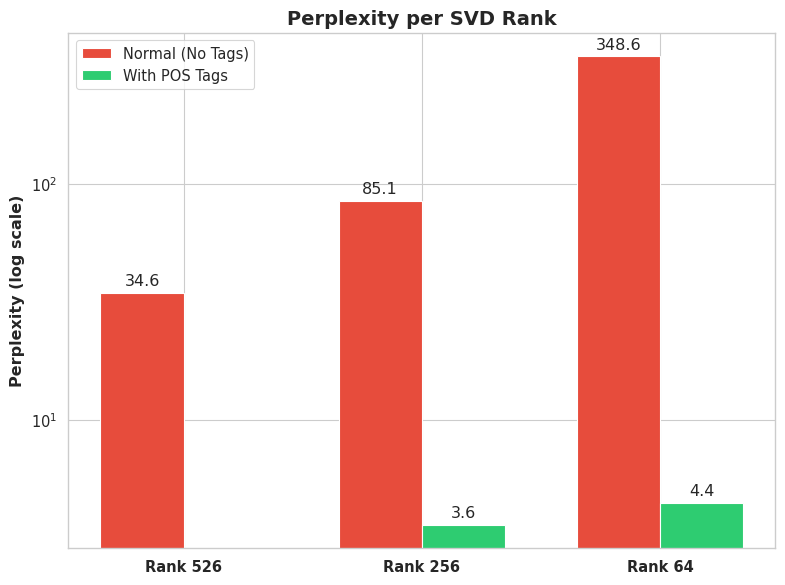

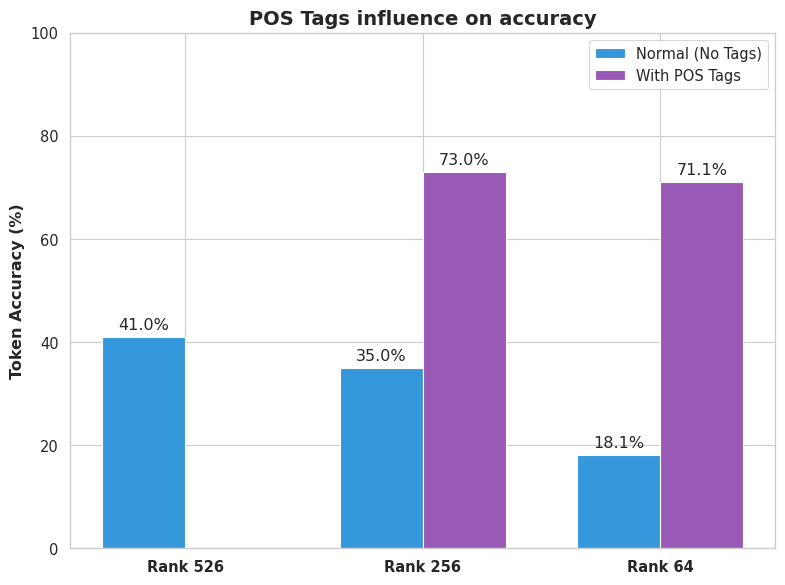

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

ranks = ['Rank 526', 'Rank 256', 'Rank 64']
ppl_normal = [34.62, 85.06, 348.59]
ppl_pos = [0, 3.58, 4.44]

acc_normal = [41.0, 35.0, 18.1]
acc_pos = [0, 73.0, 71.13]

x = np.arange(len(ranks))
width = 0.35


fig, ax1 = plt.subplots(figsize=(8, 6))

rects1 = ax1.bar(x - width/2, ppl_normal, width, label='Normal (No Tags)', color='#e74c3c')

rects2 = ax1.bar(x[1:] + width/2, ppl_pos[1:], width, label='With POS Tags', color='#2ecc71')

ax1.set_ylabel('Perplexity (log scale)', fontweight='bold')
ax1.set_title('Perplexity per SVD Rank', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(ranks, fontweight='bold')
ax1.legend()


ax1.set_yscale('log')


ax1.bar_label(rects1, padding=3, fmt='%.1f')
ax1.bar_label(rects2, padding=3, fmt='%.1f')

fig.tight_layout()
plt.savefig('perplexity_chart.png', dpi=300)
plt.show()

print("\n" + "="*50 + "\n")


fig, ax2 = plt.subplots(figsize=(8, 6))

rects3 = ax2.bar(x - width/2, acc_normal, width, label='Normal (No Tags)', color='#3498db')
rects4 = ax2.bar(x[1:] + width/2, acc_pos[1:], width, label='With POS Tags', color='#9b59b6')

ax2.set_ylabel('Token Accuracy (%)', fontweight='bold')
ax2.set_title('POS Tags influence on accuracy', fontweight='bold', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(ranks, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend()


ax2.bar_label(rects3, padding=3, fmt='%.1f%%')
ax2.bar_label(rects4, padding=3, fmt='%.1f%%')

fig.tight_layout()
plt.savefig('accuracy_chart.png', dpi=300)
plt.show()

In [14]:
wiki_prompt = "Michael Schumacher was  one of the best F1 drivers in history and he is known for his 5 consequent titles with"

print("="*60)
print("Rank 64 no taggs")
print("="*60)
ask_model(model_normal, wiki_prompt, use_tags=False)

print("\n\n" + "="*60)
print("Rank 64 with taggs")
print("="*60)
ask_model(model_pos, wiki_prompt, use_tags=True)

Rank 64 no taggs

[PROMPT]: Michael Schumacher was  one of the best F1 drivers in history and he is known for his 5 consequent titles with
[OUTPUT]: Michael Schumacher was  one of the best F1 drivers in history and he is known for his 5 consequent titles with to a ( that or " –. I as, on- - at
 also can ' like all of from by/ not is . on will -- be and and. but and and, a


Rank 64 with taggs

[PROMPT]: [PROPN] Michael [PROPN] Schumacher [AUX] was [NUM] one [ADP] of [DET] the [ADJ] best [NOUN] F1 [NOUN] drivers [ADP] in [NOUN] history [CCONJ] and [PRON] he [AUX] is [VERB] known [ADP] for [PRON] his [NUM] 5 [ADJ] consequent [NOUN] titles [ADP] with
[OUTPUT]: [PROPN] Michael [PROPN] Schumacher [AUX] was [NUM] one [ADP] of [DET] the [ADJ] best [NOUN] F1 [NOUN] drivers [ADP] in [NOUN] history [CCONJ] and [PRON] he [AUX] is [VERB] known [ADP] for [PRON] his [NUM] 5 [ADJ] consequent [NOUN] titles [ADP] with
,. (/ " to or a


In [15]:
wiki_prompt = "Michael Schumacher was  one of the best F1 drivers in history and he is known for his 5 consequent titles with"

print("="*60)
print("Rank 256 no taggs")
print("="*60)
ask_model(model_normal2, wiki_prompt, use_tags=False)

print("\n\n" + "="*60)
print("Rank 256 with taggs")
print("="*60)
ask_model(model_pos2, wiki_prompt, use_tags=True)

Rank 256 no taggs

[PROMPT]: Michael Schumacher was  one of the best F1 drivers in history and he is known for his 5 consequent titles with
[OUTPUT]: Michael Schumacher was  one of the best F1 drivers in history and he is known for his 5 consequent titles with
 (/.  or, ( a " - on to b- as d s ( 1-- . 2 w -- [ 3 — 
 t U = ( (—
 ( (



Rank 256 with taggs

[PROMPT]: [PROPN] Michael [PROPN] Schumacher [AUX] was [NUM] one [ADP] of [DET] the [ADJ] best [NOUN] F1 [NOUN] drivers [ADP] in [NOUN] history [CCONJ] and [PRON] he [AUX] is [VERB] known [ADP] for [PRON] his [NUM] 5 [ADJ] consequent [NOUN] titles [ADP] with
[OUTPUT]: [PROPN] Michael [PROPN] Schumacher [AUX] was [NUM] one [ADP] of [DET] the [ADJ] best [NOUN] F1 [NOUN] drivers [ADP] in [NOUN] history [CCONJ] and [PRON] he [AUX] is [VERB] known [ADP] for [PRON] his [NUM] 5 [ADJ] consequent [NOUN] titles [ADP] with (// ( ( end ( out ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( "
